In [53]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent


import data_loader as data_loader
import visualization as viz
import analysis_features as feats


RAW_DIR = PROJECT_ROOT / "Data"      # raw data
PROCESSED_DIR = "Processed_data" # output
FS = 50                        # sampling rate

print(f"Current Working Directory: {Path.cwd()}")
print(f"Project Root Detected:     {PROJECT_ROOT}")
print(f"Raw data path:             {RAW_DIR}")

os.makedirs(PROCESSED_DIR, exist_ok=True)

print(":)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current Working Directory: /Users/louinsleung/EEN210/Xiaoye_week3_code
Project Root Detected:     /Users/louinsleung/EEN210
Raw data path:             /Users/louinsleung/EEN210/Data
:)


In [2]:
# batch processing all csv files to parquet
print(f"batch processing from '{RAW_DIR}'.")

data_loader.batch_process(RAW_DIR, PROCESSED_DIR)

print("：）Done!")


batch processing from '/Users/louinsleung/EEN210/Data'.
Found 119 CSV files in /Users/louinsleung/EEN210/Data
[Skip] FallingForwards_p1_1_35sek_20260206_113359.parquet already exists.
[Skip] FallingForwards_p1_1_35sek_20260206_113359.csv already exists.
[Skip] FallingForwards_p4_1_35sek_20260206_115209.parquet already exists.
[Skip] FallingForwards_p4_1_35sek_20260206_115209.csv already exists.
[Skip] FallingForwards_p4_2_35sek_20260206_115310.parquet already exists.
[Skip] FallingForwards_p4_2_35sek_20260206_115310.csv already exists.
[Skip] FallingForwards_p4_3_35sek_20260206_115411.parquet already exists.
[Skip] FallingForwards_p4_3_35sek_20260206_115411.csv already exists.
[Skip] Fallingbackwards_p1_1_35sek_20260205_113403.parquet already exists.
[Skip] Fallingbackwards_p1_1_35sek_20260205_113403.csv already exists.
[Skip] Fallingbackwards_p1_2_35sek_20260205_113455.parquet already exists.
[Skip] Fallingbackwards_p1_2_35sek_20260205_113455.csv already exists.
[Skip] Fallingbackward

# data visualization
- Line plots to observe trends in acceleration and angular velocity over time.
- Scatter plots to explore relationships between features.
- Histograms to examine data distribution.

Loading representative files...
Loaded Fall (Backwards)
Loaded Cyclic ADL (Walking)
Loaded Sit-to-Stand

=== Figure 1: Time Series Trends (Line Plots) ===


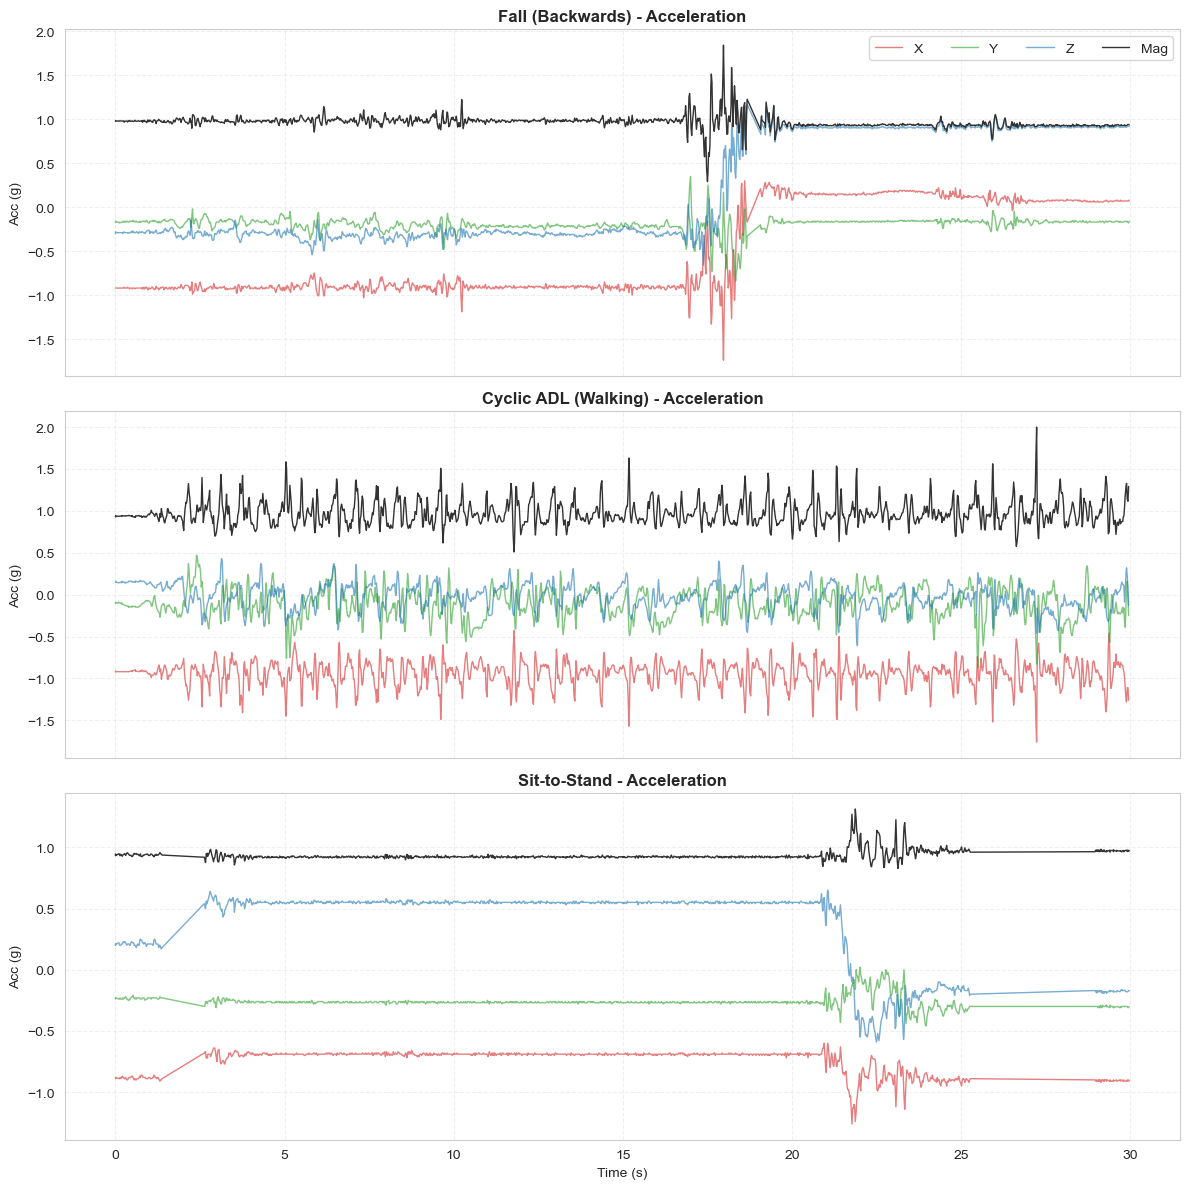

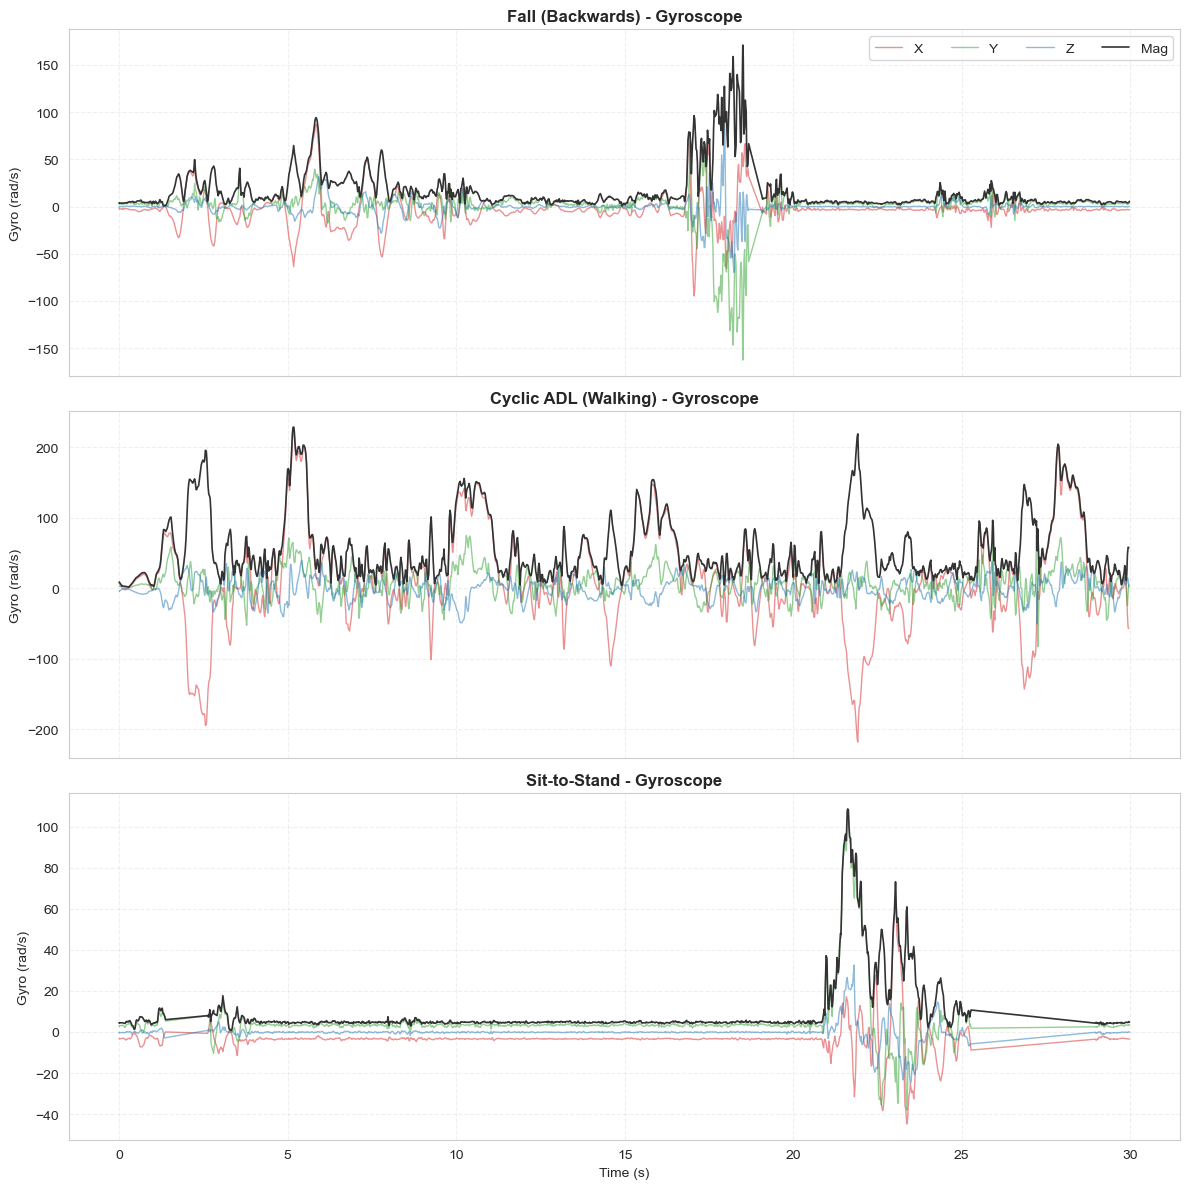


=== Figure 2: Data Distribution (Histograms) ===


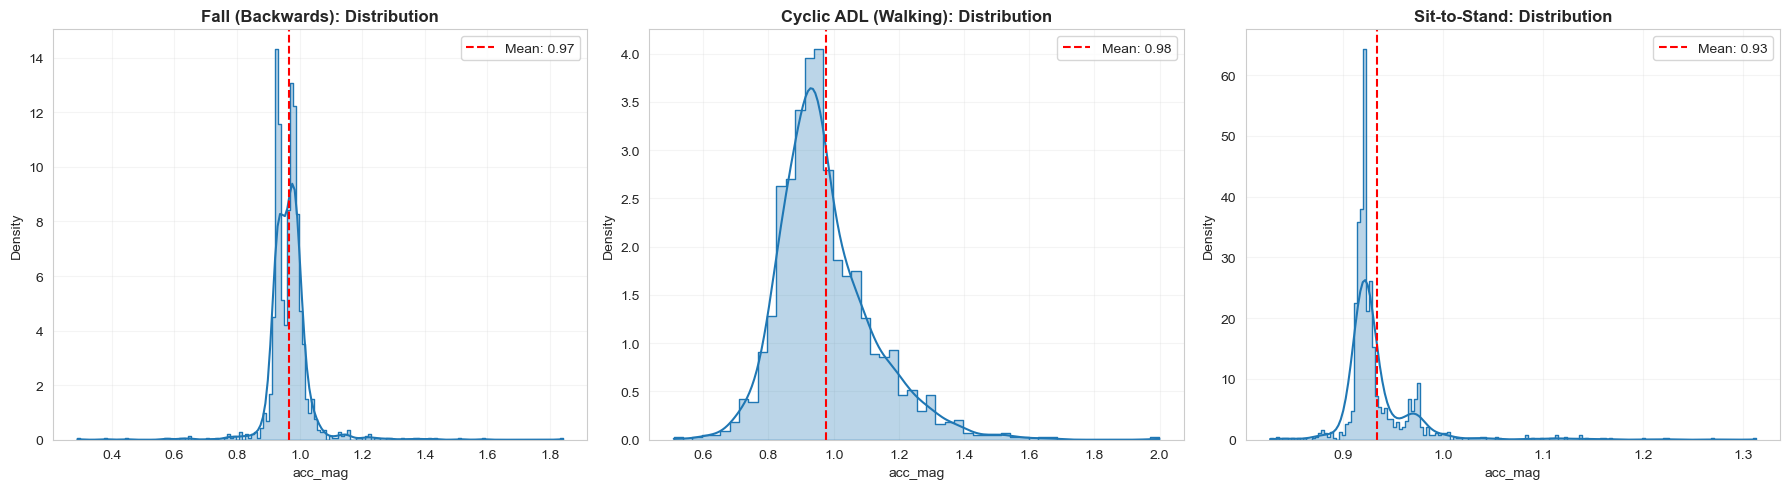


=== Figure 3: Feature Relationships (Scatter Plots) ===


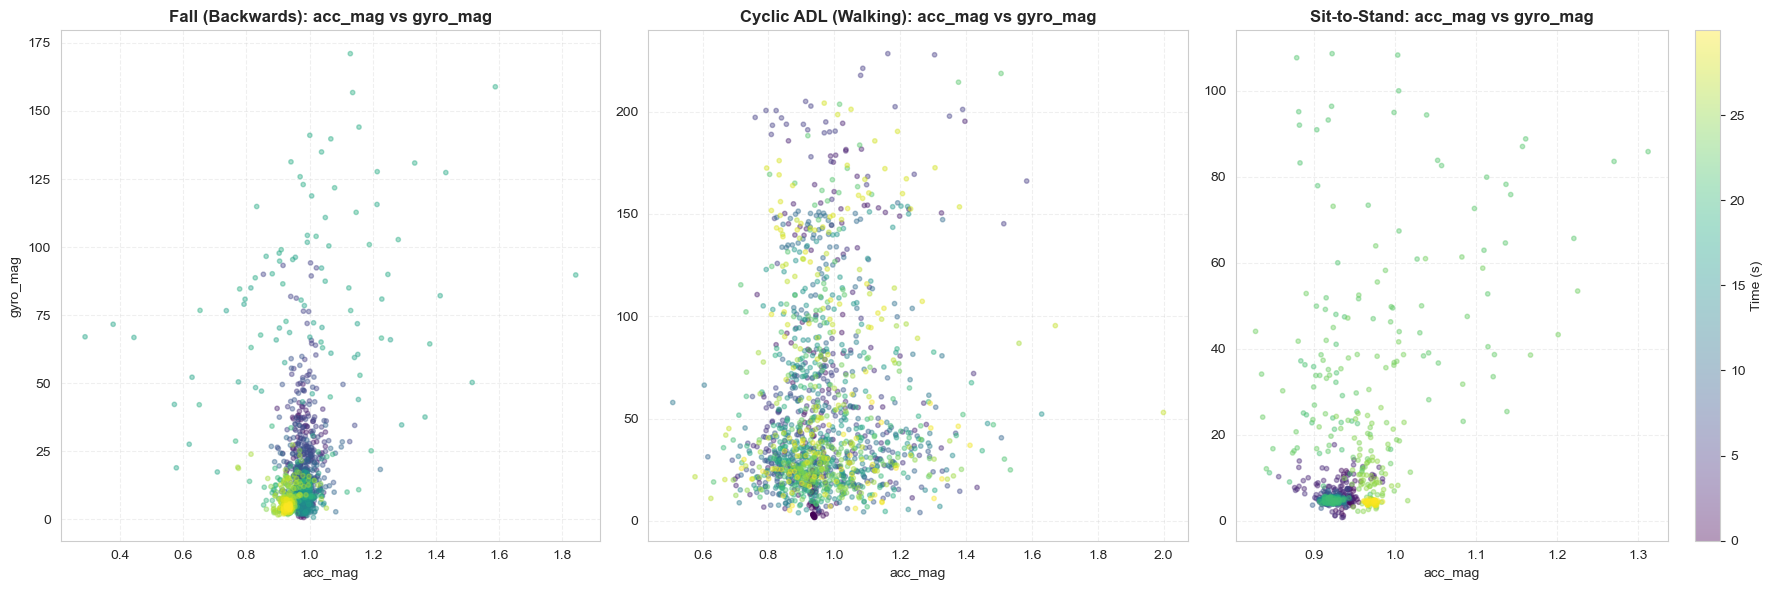

In [3]:
# raw data visualization

targets = {
    "Fall (Backwards)": "Fallingbackwards_p4_1",  
    "Cyclic ADL (Walking)": "Walking_p4_2_35sek",      
    "Sit-to-Stand": "SittingToStanding"     
}


all_files = sorted(glob.glob(os.path.join(PROCESSED_DIR, "long", "*.parquet")))
data_dict = {}


print("Loading representative files...")
for label, keyword in targets.items():
    matches = [f for f in all_files if keyword.lower() in os.path.basename(f).lower()]
    if matches:
        data_dict[label] = data_loader.load_long_parquet(matches[0])
        print(f"Loaded {label}")
    else:
        print(f" Warning: File not found for keyword '{keyword}'")


if len(data_dict) > 0:
    print("\n=== Figure 1: Time Series Trends (Line Plots) ===")
    viz.plot_raw_lines(data_dict, feature="acc_mag")
    
    print("\n=== Figure 2: Data Distribution (Histograms) ===")
    viz.plot_raw_hists(data_dict, feature="acc_mag")
    
    print("\n=== Figure 3: Feature Relationships (Scatter Plots) ===")
    viz.plot_raw_scatter(data_dict, x_col="acc_mag", y_col="gyro_mag")
else:
    print("Oh no..... No data loaded.")
  


# TSA
- Use Pandas to compute rolling averages or apply window functions to smooth the data and reduce noise.
- Highlight key patterns, anomalies, or trends in your time series.

- rolling mean

In [31]:
# load all processed parquet files 
all_parquet_paths = sorted(glob.glob(os.path.join(PROCESSED_DIR, "long", "*.parquet")))
print(f"Loading {len(all_parquet_paths)} files")

data_cache = {}
for p in all_parquet_paths:
    # Use basename as key
    fname = os.path.basename(p)
    try:
        data_cache[fname] = data_loader.load_long_parquet(p)
    except Exception as e:
        print(f"Error loading {fname}: {e}")


smoothed_cache = feats.apply_smoothing_to_dataset(data_cache, window_size=25, method='rolling')

print("\nStarting feature extraction on SMOOTHED data...")
smooth_feature_df = feats.build_feature_dataset(smoothed_cache, window_s=2.0, step_s=1.0, fs=50)

print(f"Extraction complete. Generated {len(smooth_feature_df)} windows.")
smooth_feature_df.head()

Loading 117 files
Applying rolling smoothing to 117 files...
Smoothing complete.

Starting feature extraction on SMOOTHED data...


/Users/louinsleung/EEN210/Xiaoye_week3_code/analysis_features.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)
/Users/louinsleung/EEN210/Xiaoye_week3_code/analysis_features.py:40: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Extraction complete. Generated 2732 windows.


,acc_max,acc_mean,acc_var,acc_std,gyro_max,gyro_mean,gyro_var,gyro_std,acc_skew,acc_kurtosis,acc_spec_energy,acc_spec_entropy,gyro_spec_energy,gyro_spec_entropy,file,label,activity,t_start,t_end
0,1.007730,0.983609,0.000149,0.012191,17.379322,11.132031,11.345290,3.368277,0.828197,-0.941063,3259.058403,0.623088,565314.028427,0.904893,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,0.591289,2.564783
1,0.981678,0.976888,0.000009,0.002927,13.499662,7.409906,5.125718,2.264005,-0.046988,-1.244036,3245.003283,0.627383,205811.265972,0.738125,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,1.589988,3.564779
2,0.991844,0.977864,0.000016,0.004041,12.099970,7.082976,5.486515,2.342331,-0.761019,4.255665,3259.430812,0.629250,145787.670511,0.756880,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,2.591526,4.564791
3,0.991844,0.977852,0.000018,0.004298,12.099970,7.643876,3.576134,1.891067,-0.480861,2.965765,3251.440757,0.628070,201979.870621,0.722684,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,3.589703,5.564791
4,0.985956,0.978214,0.000007,0.002627,8.728317,7.046648,0.701499,0.837555,0.267990,-0.002095,3251.935026,0.626812,192285.762484,0.748254,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,4.591483,6.564818


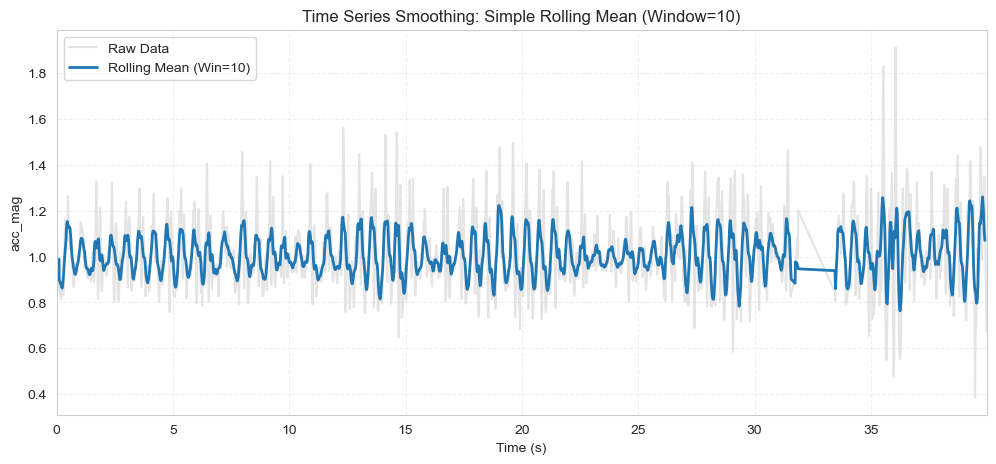

In [62]:

target_path = "Processed_data/long/Walking_Edith_2_35sek_20260202_105841.parquet"
df_test = data_loader.load_long_parquet(target_path)
if "acc_mag" not in df_test.columns:
     df_test["acc_mag"] = np.sqrt(df_test['ax']**2 + df_test['ay']**2 + df_test['az']**2)
viz.window_smooth(df_test, target_col="acc_mag", window_size=10)

# Feature extraction
- Time-domain features: Mean, variance, standard deviation, skewness.
- Frequency-domain features: Spectral entropy, energy.

In [ ]:


# Run Feature Extraction Pipeline
print("Starting feature extraction (Window=1.0s, Step=0.5s)...")
# ?? Window size = 2.0s is chosen to capture a fall event 
# ?? Step size = 1.0s
feature_df = feats.build_feature_dataset(smoothed_cache, window_s=1.0, step_s=0.5, fs=50)

print(f"Extraction complete. Generated {len(feature_df)} windows.")
print("Class distribution:")
print(feature_df["activity"].value_counts())

feature_df.head()

Starting feature extraction (Window=2.0s, Step=1.0s)...
Extraction complete. Generated 5869 windows.
Class distribution:
activity
Sit-Stand    2949
Fall         1496
Walking      1424
Name: count, dtype: int64


,acc_max,acc_mean,acc_var,acc_std,gyro_max,gyro_mean,gyro_var,gyro_std,acc_skew,acc_kurtosis,acc_spec_energy,acc_spec_entropy,gyro_spec_energy,gyro_spec_entropy,file,label,activity,t_start,t_end
0,1.006765,0.992933,0.000130,0.011402,19.736743,13.311098,17.956531,4.237515,-0.267807,-1.454382,829.341468,0.637374,162486.154338,0.693113,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,0.591289,1.564814
1,0.993868,0.978305,0.000048,0.006901,19.736743,12.833287,21.197183,4.604040,0.994846,-0.091565,797.919673,0.634129,159396.460127,0.825365,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,1.091226,2.064835
2,0.979889,0.974094,0.000007,0.002650,13.208454,9.089444,3.256358,1.804538,0.316422,-0.940190,796.935451,0.637416,76762.018773,0.775434,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,1.589988,2.564783
3,0.980699,0.976605,0.000009,0.002984,11.189086,8.072740,3.247413,1.802058,-0.237782,-1.299351,801.293709,0.637569,47485.329775,0.596201,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,2.089738,3.064821
4,0.981771,0.979445,0.000002,0.001575,7.324121,5.410029,2.008774,1.417312,-0.826817,0.019861,805.412162,0.636627,26711.804409,0.731224,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,2.591526,3.564779


/Users/louinsleung/EEN210/Xiaoye_week3_code/visualization.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=feature, data=df, palette="Set2")


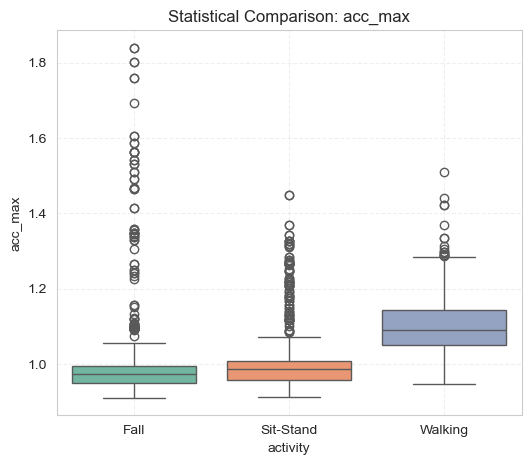

/Users/louinsleung/EEN210/Xiaoye_week3_code/visualization.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=feature, data=df, palette="Set2")


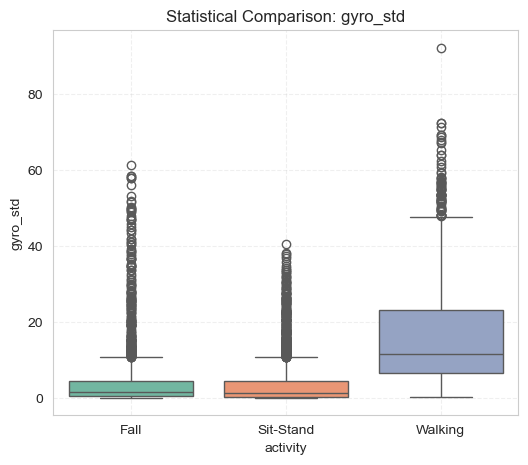

/Users/louinsleung/EEN210/Xiaoye_week3_code/visualization.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=feature, data=df, palette="Set2")


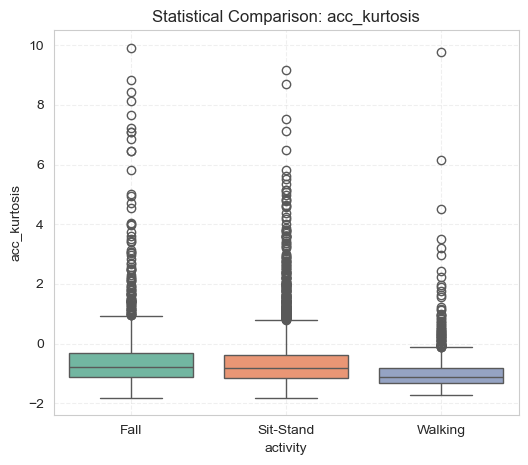

In [26]:

# check max acceleration
viz.plot_boxplot_stat(feature_df, feature="acc_max", label_col="activity")

#check Gyroscope Std
viz.plot_boxplot_stat(feature_df, feature="gyro_std", label_col="activity")

# check Kurtosis
viz.plot_boxplot_stat(feature_df, feature="acc_kurtosis", label_col="activity")


The distribution of acc_max for the 'Fall' class shows a low median but significant positive outliers. This indicates that while the majority of the fall recording consists of low-intensity periods (lying down), the specific impact events are captured as extreme values, distinct from ADLs.


Surprisingly, 'Walking' exhibits a higher median gyro_std than 'Fall'. This is because walking is a continuous dynamic activity with constant rotation, whereas a fall is a transient event often followed by a long static period. The high variability in the 'Fall' class (scattered points) reflects its unpredictable nature.

`acc_kurtosis` proves to be a robust discriminator. The 'Fall' class exhibits the highest extreme values. This confirms that falls are characterized by impulsive spikes in acceleration, distinct from the repetitive patterns of walking or the smoother transitions of sitting down."

The challenge of Fall Detection lies in distinguishing a brief, high-intensity impact (Outliers) from continuous daily activities (Walking). Features like `acc_kurtosis` and `acc_max` (specifically their extreme values) are key to identifying these transient events.

## 3D projection

Binary Class Distribution:
binary_class
Non-Fall    4373
Fall        1496
Name: count, dtype: int64

Plotting 3D Feature Space (Fall vs Non-Fall)...


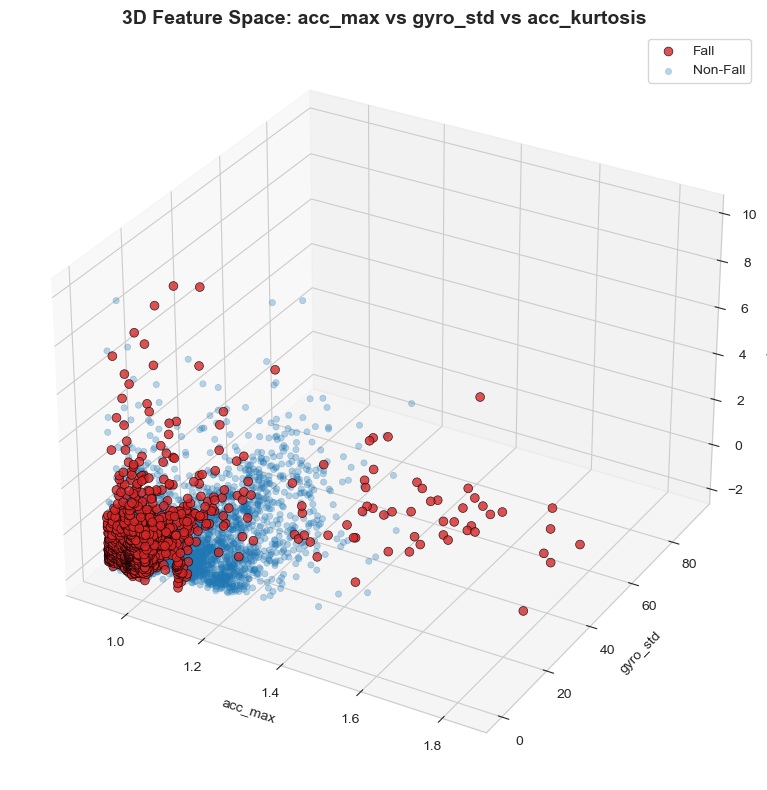

In [27]:
# %matplotlib widget
# binary labels, fall vs non-fall
# new dataframe to avoid modifying the original one
binary_df = feature_df.copy()

# If it's 'Fall', keep it. Everything else becomes 'Non-Fall'.
binary_df["binary_class"] = binary_df["activity"].apply(
    lambda x: "Fall" if x == "Fall" else "Non-Fall"
)

# distribution to check balance
print("Binary Class Distribution:")
print(binary_df["binary_class"].value_counts())

# Visualize in 3D
# Selected features based on previous boxplot analysis:
# - acc_max: Represents Impact Intensity
# - gyro_std: Represents Rotational Violence
# - acc_kurtosis: Represents Signal Impulsiveness (Spikiness)

print("\nPlotting 3D Feature Space (Fall vs Non-Fall)...")
viz.plot_3d_feature_space(
    binary_df, 
    x="acc_max", 
    y="gyro_std", 
    z="acc_kurtosis", 
    label_col="binary_class"
)

In [28]:
if "binary_df" not in locals():
    binary_df = feature_df.copy()
    binary_df["binary_class"] = binary_df["activity"].apply(lambda x: "Fall" if x == "Fall" else "Non-Fall")



# Problem: We have many features, but which ones are most relevant for distinguishing falls from non-falls?!!!
# features to analyze based on boxplot insights and domain knowledge
selected_features = [
    "acc_max",       # Impact intensity
    "gyro_std",      # Rotational intensity
    "acc_kurtosis",  # Signal impulsiveness (spikiness)
    "acc_energy",    # Total energy
    "acc_skew"       # Asymmetry of distribution
]


# result
stats_report = feats.get_statistical_report(
    binary_df, 
    selected_features, 
    group_col="binary_class", 
    target_label="Fall"
)


display(stats_report)

,Feature,Fall (Mean +/- Std),Non-Fall (Mean +/- Std),t-statistic,p-value,Significance
0,acc_max,0.99 +/- 0.10,1.03 +/- 0.08,-12.48,1.44e-34,***
1,gyro_std,5.01 +/- 9.31,8.01 +/- 11.25,-10.17,6.40e-24,***
2,acc_kurtosis,-0.53 +/- 1.13,-0.71 +/- 0.91,5.51,4.04e-08,***
3,acc_skew,0.06 +/- 0.69,0.05 +/- 0.59,0.57,5.68e-01,ns


**problem** unbalanced time distribution
---> filter for active events(only for statistical analysis)

In [29]:
import analysis_features as feats


filtered_df = binary_df.copy()

silent_fall_indices = filtered_df[
    (filtered_df["binary_class"] == "Fall") & 
    (filtered_df["acc_max"] < 1.5)
].index


active_stats_df = filtered_df.drop(silent_fall_indices)

print(f"Original Windows: {len(binary_df)}")
print(f"Active Windows (High Impact Falls + All Non-Falls): {len(active_stats_df)}")



refined_report = feats.get_statistical_report(
    active_stats_df, 
    selected_features, 
    group_col="binary_class", 
    target_label="Fall"
)

display(refined_report)

Original Windows: 5869
Active Windows (High Impact Falls + All Non-Falls): 4394


,Feature,Fall (Mean +/- Std),Non-Fall (Mean +/- Std),t-statistic,p-value,Significance
0,acc_max,1.63 +/- 0.12,1.03 +/- 0.08,23.90,3.16e-16,***
1,gyro_std,43.71 +/- 8.76,8.01 +/- 11.25,18.61,3.11e-14,***
2,acc_kurtosis,0.06 +/- 1.69,-0.71 +/- 0.91,2.07,5.18e-02,ns
3,acc_skew,1.02 +/- 0.47,0.05 +/- 0.59,9.50,6.48e-09,***


# Event Segmentation
Isolate specific events from your time series, such as potential falls. Suggested methods:
- Threshold-based segmentation.
- More advanced techniques if appropriate for your data.

Detected 5 events:
  Event 1: 12.20s -> 14.90s (Duration: 2.70s)
  Event 2: 18.80s -> 20.98s (Duration: 2.17s)
  Event 3: 27.10s -> 29.64s (Duration: 2.53s)
  Event 4: 34.84s -> 36.54s (Duration: 1.70s)
  Event 5: 38.48s -> 39.76s (Duration: 1.28s)


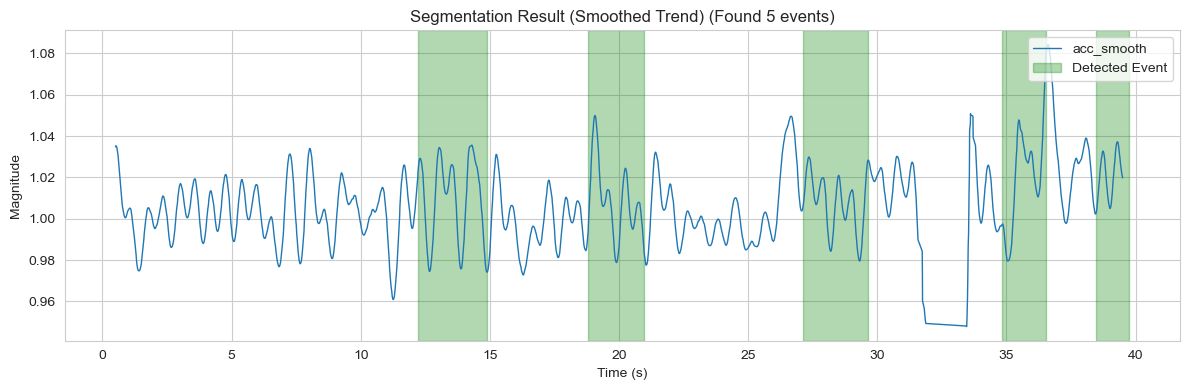

In [63]:

# parameters for event detection
# threshold = 0.2 

detected_events = feats.detect_events(
    df_test, 
    signal_col="acc_mag", 
    fs=50, 
    window_s=0.5,   
    threshold=0.2,  
    merge_gap_s=1.5 # gap less than 1.5s is considered the same event
)

# add smoothing data
df_test["acc_smooth"] = df_test["acc_mag"].rolling(
    window=50, 
    win_type='gaussian', 
    center=True
).mean(std=10)

print(f"Detected {len(detected_events)} events:")
for i, (s, e) in enumerate(detected_events):
    print(f"  Event {i+1}: {s:.2f}s -> {e:.2f}s (Duration: {e-s:.2f}s)")


viz.plot_segmentation(
    df_test, 
    detected_events, 
    title=f"Segmentation Result (Smoothed Trend)", 
    signal_col="acc_smooth" )

`rolling_std`
$$\sigma = \sqrt{\frac{1}{N}\sum (x_i - \bar{x})^2}$$
std<0.2--> noise

std>0.2--> event

`merging_gap_s`
the gap (signal interruption due to strenuous exercise) <1.5s, take them as a same event but different stages

----------
Feature Computation: We calculated the Rolling Standard Deviation (Window=0.5s) of the acceleration magnitude. This metric serves as a proxy for "kinetic energy" or "activity intensity," which is more robust to sensor orientation than raw amplitude.

Thresholding: A threshold of 0.2 was applied. Periods exceeding this value were marked as "Active Regions."

Post-processing (Merging): To prevent fragmentation of single events (e.g., a fall followed by a bounce), adjacent active regions separated by less than 1.5s were merged into a single continuous event.



**problem**
how to select threshold?

In [13]:
import preprocessing as pre



if 'binary_df' not in locals():
    print("Ohno..... No feature dataset available for preprocessing.")
else:
   
    clean_df = pre.clean_feature_matrix(binary_df)
    

    feature_columns = [
        "acc_max", "acc_mean", "acc_std", "acc_skew", "acc_kurtosis", "acc_energy",
        "gyro_max", "gyro_mean", "gyro_std", "gyro_energy"
    ]
    

    valid_features = [c for c in feature_columns if c in clean_df.columns]
    
    # remove outliers using IQR method with a factor of 3.0 (more aggressive)
    clean_df = pre.remove_outliers(clean_df, valid_features, factor=3.0)
    
    # Normalization z-score
    final_dataset, scaler = pre.normalize_features(clean_df, valid_features, method='z-score')
    

    print("\nOriginal Means (acc_max):", binary_df["acc_max"].mean())
    print("Scaled Means (acc_max):  ", round(final_dataset["acc_max"].mean(), 2))
    
    display(final_dataset.head())
    
    final_dataset.to_csv(os.path.join(PROCESSED_DIR, "final_dataset_week3.csv"), index=False)
    print(f"Dataset saved to {os.path.join(PROCESSED_DIR, 'final_dataset_week3.csv')}")

[Preprocessing] Outliers removed: 179 rows (Factor=3.0).
[Preprocessing] Features normalized using z-score.

Original Means (acc_max): 1.1862267902904051
Scaled Means (acc_max):   0.0


,acc_max,acc_mean,acc_var,acc_std,gyro_max,gyro_mean,gyro_var,gyro_std,acc_skew,acc_kurtosis,acc_spec_energy,acc_spec_entropy,gyro_spec_energy,gyro_spec_entropy,file,label,activity,t_start,t_end,binary_class
0,-0.566345,0.107358,0.000342,-0.540181,-0.493451,-0.422458,21.340068,-0.489855,-0.363729,-1.003133,3255.967960,0.625310,616425.800099,1.235684,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,0.591289,2.564783,Fall
1,-0.626097,-0.113284,0.000115,-0.649305,-0.694101,-0.604840,9.818302,-0.594419,-0.841345,-0.698181,3244.977935,0.628869,214148.726482,1.017517,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,1.589988,3.564779,Fall
3,-0.051546,-0.035357,0.001789,-0.205148,-0.457293,-0.577021,17.207601,-0.523018,-0.447625,2.159637,3253.782264,0.635088,217342.778498,1.339828,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,3.589703,5.564791,Fall
4,-0.245700,-0.058229,0.001145,-0.324126,-0.592028,-0.611534,11.264197,-0.578742,1.094880,0.197320,3255.184582,0.643388,223628.462071,1.697422,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,4.591483,6.564818,Fall
5,-0.389470,-0.090230,0.000558,-0.467872,-0.592028,-0.617604,15.108790,-0.541396,0.891640,0.366738,3253.030056,0.630695,209789.912086,1.765363,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,5.591104,7.564821,Fall


Dataset saved to Processed_data/final_dataset_week3.csv
